  ticket_id channel                                   customer_message  \
0  TKT00001    chat  I need information about the payment process. ...   
1  TKT00002   phone      I need information about the payment process.   
2  TKT00003   email  The refund process was fast and convenient. I ...   
3  TKT00004  social  My refund is still pending and this experience...   
4  TKT00005    chat   Please tell me how to update my account details.   

  sentiment_label  word_count  urgent_flag  
0         neutral          18            1  
1         neutral           7            0  
2        positive          12            0  
3        negative          15            1  
4         neutral           9            0  
Dataset shape: (1500, 6)
Number of records: 1500
Target classes:
<StringArray>
['neutral', 'positive', 'negative']
Length: 3, dtype: str
Sample customer messages:
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
I need inform

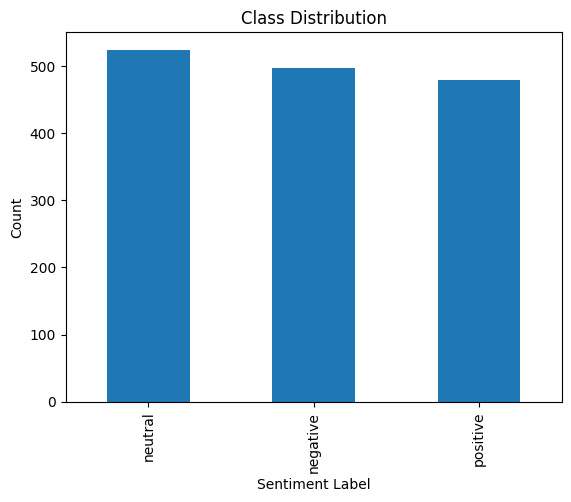

In [12]:
# Task 1- Dataset Understanding

import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df= pd.read_csv('C:\\Users\\DELL\\Desktop\\bitsom_ba_2511333_Kashid_Ashish_Assignment5\\BITSoM BA - Module 5 - Dataset\\ai_project_synthetic_datasets\\part_3_nlp_sequence_modeling\\customer_support_text_classification.csv')

# Display the first few rows of the dataset
print(df.head())

# Dataset shape
print(f"Dataset shape: {df.shape}")

# Number of records
print(f"Number of records: {len(df)}")

# Target Labels/Classes
print("Target classes:")
print(df['sentiment_label'].unique())

# Sample text messages
print("Sample customer messages:")
for i in range(5):
    print(df['customer_message'][i])

# Average length of text
df['text_length'] = df['customer_message'].apply(len)
average_length = df['text_length'].mean()
print(f"Average length of customer messages: {average_length:.2f} characters")

# Class distribution
print("Class distribution:")
print(df['sentiment_label'].value_counts())


# plotting the class distribution
df['sentiment_label'].value_counts().plot(kind='bar', title='Class Distribution')
plt.xlabel('Sentiment Label')
plt.ylabel('Count')
plt.show()



In [13]:
# Task 2- Data Preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Download nltk resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [14]:
# Load stop words
stop_words = set(stopwords.words('english'))
# Function to preprocess text
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove numbers and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Tokenize the text
    tokens = word_tokenize(text)
    
    # Remove stop words
    tokens = [word for word in tokens if word not in stop_words]

    # Join tokens back to string
    cleaned_ = ' '.join(tokens)
    
    return cleaned_
# Apply preprocessing to the customer messages
df['cleaned_message'] = df['customer_message'].apply(preprocess_text)

# Show original and cleaned messages
for i in range(5):
    print("Original:", df['customer_message'][i])
    print("Cleaned:", df['cleaned_message'][i])
    print()

# Convert text to sequences using Keras Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
# Initialize the tokenizer
tokenizer = Tokenizer(num_words=5000)
# Fit the tokenizer on the cleaned messages
tokenizer.fit_on_texts(df['cleaned_message'])
# Convert text to sequences
sequences = tokenizer.texts_to_sequences(df['cleaned_message'])
# Apply padding to ensure uniform sequence length
max_sequence_length = 20
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post', truncating='post')
# Display the first few padded sequences
print("Original Text:")
print(df['customer_message'][0])
print("\nSequence:")
print(sequences[0])
print("\nPadded Sequence:")
print(padded_sequences[0])
print("\nShape of padded sequences:", padded_sequences.shape)



Original: I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.
Cleaned: need information payment process ticket number please respond soon possible

Original: I need information about the payment process.
Cleaned: need information payment process

Original: The refund process was fast and convenient. I appreciate the quick response.
Cleaned: refund process fast convenient appreciate quick response

Original: My refund is still pending and this experience is frustrating. My ticket number is 33927.
Cleaned: refund still pending experience frustrating ticket number

Original: Please tell me how to update my account details.
Cleaned: please tell update account details

Original Text:
I need information about the payment process. My ticket number is 78732. Please respond as soon as possible.

Sequence:
[14, 104, 64, 18, 1, 2, 3, 4, 5, 6]

Padded Sequence:
[ 14 104  64  18   1   2   3   4   5   6   0   0   0   0   0   0   0   0
   0   0

In [15]:
# Task 3-Text Vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

#Features and Targets
X = df['cleaned_message']
y = df['sentiment_label']

# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf_vectorizer.fit_transform(X)
print("TF-IDF feature matrix shape:", X_tfidf.shape)

# Tokenization and Padding
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(X)
sequences = tokenizer.texts_to_sequences(X)
max_sequence_length = 20
padded_sequences = pad_sequences(sequences, maxlen=max_sequence_length, padding='post', truncating='post')
print("Padded sequences shape:", padded_sequences.shape)
# Dsplay Example of TF-IDF vector and padded sequence for the first message
print("Original Text:")
print(X[0])
print("\nSequence:")
print(sequences[0])
print("\nPadded Sequence:")
print(padded_sequences[0])


TF-IDF feature matrix shape: (1500, 146)
Padded sequences shape: (1500, 20)
Original Text:
need information payment process ticket number please respond soon possible

Sequence:
[14, 104, 64, 18, 1, 2, 3, 4, 5, 6]

Padded Sequence:
[ 14 104  64  18   1   2   3   4   5   6   0   0   0   0   0   0   0   0
   0   0]


# Why text must be converted into vectors before being used by a model-
ML & DL model works only with numerical data and cannot understand raw text directly. Text data must be converted into numerical vectors so that mathematical computation can be performed.
Vectorization do this conversion task by preserving useful information such as sequence, frequency etc. Without vectorization model would not able to identify the pattern, relationship and make prediction from textual data.


In [16]:
# Task 4 - Baseline Model Building
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)
# Build a Logistic Regression model
model = LogisticRegression(max_iter=1000)
# Train the model
model.fit(X_train, y_train)
# Make predictions on the test set
y_pred = model.predict(X_test)
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00       109
     neutral       1.00      1.00      1.00       104
    positive       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Confusion Matrix:
[[109   0   0]
 [  0 104   0]
 [  0   0  87]]


In [17]:
# Simple dense model using Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.preprocessing import LabelEncoder
# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y_encoded, test_size=0.2, random_state=42)
# Convert sparse matrix to dense for Keras
X_train_nn = X_train.toarray()
X_test_nn = X_test.toarray()

# Build a simple dense neural network model
dense_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])
# Compile the model
dense_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Train the model
dense_model.fit(X_train_nn, y_train, epochs=10, batch_size=32, validation_data=(X_test_nn, y_test))
# Evaluate the model
loss, accuracy = dense_model.evaluate(X_test_nn, y_test)
print(f"Neural Network Accuracy: {accuracy:.4f}")
print(f"Loss: {loss:.4f}")



Epoch 1/10


c:\Users\DELL\Desktop\bitsom_ba_2511333_Kashid_Ashish_Assignment5\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8317 - loss: 0.9335 - val_accuracy: 1.0000 - val_loss: 0.6657
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9942 - loss: 0.3503 - val_accuracy: 1.0000 - val_loss: 0.0775
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0393 - val_accuracy: 1.0000 - val_loss: 0.0110
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0105 - val_accuracy: 1.0000 - val_loss: 0.0043
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0054 - val_accuracy: 1.0000 - val_loss: 0.0023
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 1.0000 - val_loss: 0.0015
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0023 - val_accuracy: 1.0000 - val_loss: 0.0010
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 7.5040e-0

In [18]:
# Save Sample Predictions
sample_output = []

for actual, pred in zip(y_test[:10], y_pred[:10]):
    sample_output.append(f"Actual:{actual} | Predicted:{pred}")
with open('results/sample_predictions.txt', 'w') as f:
    for line in sample_output:
        f.write(str(line) + "\n")


In [19]:
# Sequence model using LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
# Encode target labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['sentiment_label'])
print(label_encoder.classes_)
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Vocabulary size for embedding layer
vocab_size = 5000
#Build the LSTM model
lstm_model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64, input_length=max_sequence_length),
    LSTM(64, return_sequences=False),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')
])
# Compile the model
lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# LSTM model Summary
lstm_model.summary()
# Train the model
history=lstm_model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.2)
# Evaluate the model
loss, accuracy = lstm_model.evaluate(X_test, y_test)
print(f"LSTM Model Accuracy: {accuracy:.4f}")
print(f"Loss: {loss:.4f}")
# Predtictions
predictions = lstm_model.predict(X_test)
predicted_classes = predictions.argmax(axis=1)
print("Predicted labels:")
print(predicted_classes[:10])
print("Actual labels:")
print(y_test[:10])

['negative' 'neutral' 'positive']


c:\Users\DELL\Desktop\bitsom_ba_2511333_Kashid_Ashish_Assignment5\venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.3771 - loss: 1.0767 - val_accuracy: 0.4750 - val_loss: 0.9283
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.6729 - loss: 0.5446 - val_accuracy: 0.6417 - val_loss: 0.4863
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.7927 - loss: 0.4027 - val_accuracy: 0.9875 - val_loss: 0.2712
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9906 - loss: 0.1092 - val_accuracy: 1.0000 - val_loss: 0.0179
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 1.0000 - loss: 0.0094 - val_accuracy: 1.0000 - val_loss: 0.0058
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 1.0000 - loss: 0.0055
LSTM Model Accuracy: 1.0000
Loss: 0.0055
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step
Predicted labels:
[2 2 0 0 2 1 2 2 1 1]
Actual labels:
[2 2 0 0 2 1 2 2 1 1]


### Input Sequence
The cleaned customer message are converted into numerical sequence using Tokenizer.Each word is assigned a unique integer index.
### Embedding Layer
The embedding layer converts integer word indices in to dense vector representation. This help the model learn semantic relationships between words.
### LSTM Layer
This layer process the text sequentially and also remember important contextual information from earlier word in the sentence. It overcome short term memory problems found in Traditional RNN's.
### Output Layer
The final dense layer uses softmax activation to predict the semantic class:
-positive
-negative
-neutral
### Loss Function 
Sparse categorical crossentropy is used because this multiclass classification problem.
### Evaluation Metrics
Accuracy is used to measure percentage of correctly classified customer message.
